In [1]:
from google.colab import drive
import pandas as pd

# Monter Google Drive
drive.mount('/content/drive')

# Charger le fichier depuis Drive
df = pd.read_csv('/content/drive/MyDrive/data_science/UK_Accident.csv')

# Vérifier que ça a bien marché
# print(f"✅ Données chargées : {df.shape}")
# print(df.head(5))
print("Colonnes et types :")
print(df.dtypes)

Mounted at /content/drive
Colonnes et types :
Unnamed: 0                                       int64
Accident_Index                                  object
Location_Easting_OSGR                          float64
Location_Northing_OSGR                         float64
Longitude                                      float64
Latitude                                       float64
Police_Force                                     int64
Accident_Severity                                int64
Number_of_Vehicles                               int64
Number_of_Casualties                             int64
Date                                            object
Day_of_Week                                      int64
Time                                            object
Local_Authority_(District)                       int64
Local_Authority_(Highway)                       object
1st_Road_Class                                   int64
1st_Road_Number                                  int64
Road_Type          

In [2]:
# Vérifier les valeurs manquantes
print(f"\nPourcentage de valeurs manquantes par colonne :")
print((df.isnull().sum() / len(df) * 100).round(2))


Pourcentage de valeurs manquantes par colonne :
Unnamed: 0                                      0.00
Accident_Index                                  0.00
Location_Easting_OSGR                           0.01
Location_Northing_OSGR                          0.00
Longitude                                       0.01
Latitude                                        0.00
Police_Force                                    0.00
Accident_Severity                               0.00
Number_of_Vehicles                              0.00
Number_of_Casualties                            0.00
Date                                            0.00
Day_of_Week                                     0.00
Time                                            0.01
Local_Authority_(District)                      0.00
Local_Authority_(Highway)                       0.00
1st_Road_Class                                  0.00
1st_Road_Number                                 0.00
Road_Type                                       0.

In [3]:
# Définir le seuil (20%)
threshold = 0.2

# Calcul du pourcentage de valeurs manquantes par colonne
missing_ratio = df.isnull().mean()

# Garder uniquement les colonnes avec <= 20% de valeurs manquantes
df_clean = df.loc[:, missing_ratio <= threshold]

# Afficher les colonnes supprimées (optionnel)
dropped_columns = missing_ratio[missing_ratio > threshold].index
print("Colonnes supprimées :", list(dropped_columns))

# Nouveau dataset
df_clean.head()

Colonnes supprimées : ['Junction_Control', 'Special_Conditions_at_Site', 'Carriageway_Hazards']


,Unnamed: 0,Accident_Index,Location_Easting_OSGR,Location_Northing_OSGR,Longitude,Latitude,Police_Force,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,...,2nd_Road_Number,Pedestrian_Crossing-Human_Control,Pedestrian_Crossing-Physical_Facilities,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Urban_or_Rural_Area,Did_Police_Officer_Attend_Scene_of_Accident,LSOA_of_Accident_Location,Year
0,0,200501BS00001,525680.0,178240.0,-0.191170,51.489096,1,2,1,1,...,0,None within 50 metres,Zebra crossing,Daylight: Street light present,Raining without high winds,Wet/Damp,1,Yes,E01002849,2005
1,1,200501BS00002,524170.0,181650.0,-0.211708,51.520075,1,3,1,1,...,0,None within 50 metres,Pedestrian phase at traffic signal junction,Darkness: Street lights present and lit,Fine without high winds,Dry,1,Yes,E01002909,2005
2,2,200501BS00003,524520.0,182240.0,-0.206458,51.525301,1,3,2,1,...,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lights present and lit,Fine without high winds,Dry,1,Yes,E01002857,2005
3,3,200501BS00004,526900.0,177530.0,-0.173862,51.482442,1,3,1,1,...,0,None within 50 metres,No physical crossing within 50 meters,Daylight: Street light present,Fine without high winds,Dry,1,Yes,E01002840,2005
4,4,200501BS00005,528060.0,179040.0,-0.156618,51.495752,1,3,1,1,...,0,None within 50 metres,No physical crossing within 50 meters,Darkness: Street lighting unknown,Fine without high winds,Wet/Damp,1,Yes,E01002863,2005


In [4]:
# Colonnes numériques
num_cols = df_clean.select_dtypes(include=['number']).columns.tolist()

# Colonnes catégorielles (object, category, etc.)
cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

# Affichage (optionnel)
print("Colonnes numériques :", num_cols)
print("Colonnes catégorielles :", cat_cols)

Colonnes numériques : ['Unnamed: 0', 'Location_Easting_OSGR', 'Location_Northing_OSGR', 'Longitude', 'Latitude', 'Police_Force', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Day_of_Week', 'Local_Authority_(District)', '1st_Road_Class', '1st_Road_Number', 'Speed_limit', '2nd_Road_Class', '2nd_Road_Number', 'Urban_or_Rural_Area', 'Year']
Colonnes catégorielles : ['Accident_Index', 'Date', 'Time', 'Local_Authority_(Highway)', 'Road_Type', 'Pedestrian_Crossing-Human_Control', 'Pedestrian_Crossing-Physical_Facilities', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Did_Police_Officer_Attend_Scene_of_Accident', 'LSOA_of_Accident_Location']


In [5]:
# Analyse des valeurs manquantes par type de colonne
print("="*60)
print("📊 ANALYSE DES VALEURS MANQUANTES")
print("="*60)

# Colonnes numériques
print("\n🔢 COLONNES NUMÉRIQUES:")
numeric_missing = df_clean[num_cols].isnull().sum()
numeric_missing_pct = (numeric_missing / len(df_clean)) * 100
numeric_summary = pd.DataFrame({
    'Missing Count': numeric_missing,
    'Missing %': numeric_missing_pct
}).sort_values('Missing %', ascending=False)
print(numeric_summary[numeric_summary['Missing %'] > 0].to_string())

# Colonnes catégorielles
print("\n📝 COLONNES CATÉGORIELLES:")
categorical_missing = df_clean[cat_cols].isnull().sum()
categorical_missing_pct = (categorical_missing / len(df_clean)) * 100
categorical_summary = pd.DataFrame({
    'Missing Count': categorical_missing,
    'Missing %': categorical_missing_pct
}).sort_values('Missing %', ascending=False)
print(categorical_summary[categorical_summary['Missing %'] > 0].to_string())

# Statistiques globales
print(f"\n📈 RÉSUMÉ GLOBAL:")
print(f"Colonnes numériques avec missing: {(numeric_missing > 0).sum()}/{len(num_cols)}")
print(f"Colonnes catégorielles avec missing: {(categorical_missing > 0).sum()}/{len(cat_cols)}")

📊 ANALYSE DES VALEURS MANQUANTES

🔢 COLONNES NUMÉRIQUES:
                       Missing Count  Missing %
Location_Easting_OSGR            101   0.006715
Longitude                        101   0.006715

📝 COLONNES CATÉGORIELLES:
                                         Missing Count  Missing %
LSOA_of_Accident_Location                       108238   7.195958
Time                                               117   0.007778
Pedestrian_Crossing-Physical_Facilities             34   0.002260
Pedestrian_Crossing-Human_Control                   17   0.001130

📈 RÉSUMÉ GLOBAL:
Colonnes numériques avec missing: 2/18
Colonnes catégorielles avec missing: 4/12


In [6]:
# Imputation des valeurs manquantes
print("="*60)
print("🔄 IMPUTATION DES VALEURS MANQUANTES")
print("="*60)

# 1. Colonnes numériques avec très peu de missing (< 1%)
#    Stratégie: Imputation par la médiane (robuste aux outliers)
for col in ['Location_Easting_OSGR', 'Longitude']:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        missing_count = df_clean[col].isnull().sum()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"✅ {col}: imputé par médiane ({median_val:.2f}) - {missing_count} valeurs")

# 2. Colonnes catégorielles avec très peu de missing (< 1%)
#    Stratégie: Imputation par le mode (valeur la plus fréquente)
for col in ['Time', 'Pedestrian_Crossing-Physical_Facilities', 'Pedestrian_Crossing-Human_Control']:
    if col in df_clean.columns:
        mode_val = df_clean[col].mode()[0] if not df_clean[col].mode().empty else "Unknown"
        missing_count = df_clean[col].isnull().sum()
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"✅ {col}: imputé par mode ('{mode_val}') - {missing_count} valeurs")

# 3. Colonne LSOA_of_Accident_Location (7.2% de missing)
#    Stratégie: Créer une catégorie "Unknown" car c'est une localisation
if 'LSOA_of_Accident_Location' in df_clean.columns:
    missing_count = df_clean['LSOA_of_Accident_Location'].isnull().sum()
    df_clean['LSOA_of_Accident_Location'].fillna("Unknown", inplace=True)
    print(f"✅ LSOA_of_Accident_Location: imputé par 'Unknown' - {missing_count} valeurs")

# Vérification finale
print("\n" + "="*60)
print("✅ VÉRIFICATION FINALE:")
print("="*60)
print(f"Valeurs manquantes restantes: {df_clean.isnull().sum().sum()}")
print(f"Shape final: {df_clean.shape}")

🔄 IMPUTATION DES VALEURS MANQUANTES
✅ Location_Easting_OSGR: imputé par médiane (439960.00) - 101 valeurs
✅ Longitude: imputé par médiane (-1.40) - 101 valeurs


/tmp/ipykernel_11029/1373848989.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)
/tmp/ipykernel_11029/1373848989.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col].fillna(median_val, inplace=True)
/tmp/ipykernel_11029/1373848989.py:21: FutureWarning: A value is trying to be set

✅ Time: imputé par mode ('17:00') - 117 valeurs
✅ Pedestrian_Crossing-Physical_Facilities: imputé par mode ('No physical crossing within 50 meters') - 34 valeurs
✅ Pedestrian_Crossing-Human_Control: imputé par mode ('None within 50 metres') - 17 valeurs
✅ LSOA_of_Accident_Location: imputé par 'Unknown' - 108238 valeurs

✅ VÉRIFICATION FINALE:


/tmp/ipykernel_11029/1373848989.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['LSOA_of_Accident_Location'].fillna("Unknown", inplace=True)
/tmp/ipykernel_11029/1373848989.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['LSOA_of_Accident_Location'].fillna("Unknown", inplace=True)


Valeurs manquantes restantes: 0
Shape final: (1504150, 30)


In [7]:
# Extraction des features temporelles AVANT suppression
print("="*60)
print("⏰ EXTRACTION DES FEATURES TEMPORELLES")
print("="*60)

# 1. Convertir la colonne Date en datetime
if 'Date' in df_clean.columns:
    df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y', errors='coerce')

    # Extraire le mois
    df_clean['Month'] = df_clean['Date'].dt.month
    print("✅ Mois extrait de Date -> colonne 'Month'")

    # Garder l'année (déjà présente)
    print("✅ Année déjà présente dans 'Year'")

# 2. Convertir Time en heure numérique
if 'Time' in df_clean.columns:
    # Extraire l'heure (premiers caractères avant le ':')
    df_clean['heure_num'] = df_clean['Time'].astype(str).str.split(':').str[0].astype(int)
    print("✅ Heure extraite de Time -> colonne 'heure_num'")

# Afficher les nouvelles colonnes
print(f"\n📊 Nouvelles colonnes créées:")
print(f"   - Month (valeurs: {df_clean['Month'].min()} à {df_clean['Month'].max()})")
print(f"   - heure_num (valeurs: {df_clean['heure_num'].min()} à {df_clean['heure_num'].max()})")

print(f"\n✅ Shape après extraction: {df_clean.shape}")

⏰ EXTRACTION DES FEATURES TEMPORELLES


/tmp/ipykernel_11029/2457681079.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y', errors='coerce')
/tmp/ipykernel_11029/2457681079.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Month'] = df_clean['Date'].dt.month


✅ Mois extrait de Date -> colonne 'Month'
✅ Année déjà présente dans 'Year'
✅ Heure extraite de Time -> colonne 'heure_num'

📊 Nouvelles colonnes créées:
   - Month (valeurs: 1 à 12)
   - heure_num (valeurs: 0 à 23)

✅ Shape après extraction: (1504150, 32)


/tmp/ipykernel_11029/2457681079.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['heure_num'] = df_clean['Time'].astype(str).str.split(':').str[0].astype(int)


In [8]:
# Suppression des colonnes inutilisables
print("="*60)
print("🗑️ SUPPRESSION DES COLONNES INUTILISABLES")
print("="*60)

# Colonnes à supprimer:
columns_to_drop = [
    'Unnamed: 0',              # Index inutile
    'Accident_Index',          # Identifiant unique
    'Location_Easting_OSGR',   # Coordonnées trop précises
    'Location_Northing_OSGR',  # Coordonnées trop précises
    'Longitude',               # Coordonnées trop précises
    'Latitude',                # Coordonnées trop précises
    'LSOA_of_Accident_Location', # Zone trop fine
    'Date',                    # Déjà extrait (Month, Year)
    'Time',                    # Déjà extrait (heure_num)
]

# Vérifier quelles colonnes existent
cols_to_drop = [col for col in columns_to_drop if col in df_clean.columns]
print(f"📌 Colonnes supprimées ({len(cols_to_drop)}):")
for col in cols_to_drop:
    print(f"   - {col}")

# Supprimer les colonnes
df_clean = df_clean.drop(columns=cols_to_drop)

print(f"\n✅ Nouveau shape après suppression: {df_clean.shape}")
print(f"\n📊 Colonnes restantes ({len(df_clean.columns)}):")
for i, col in enumerate(df_clean.columns, 1):
    print(f"   {i:2}. {col}")

🗑️ SUPPRESSION DES COLONNES INUTILISABLES
📌 Colonnes supprimées (9):
   - Unnamed: 0
   - Accident_Index
   - Location_Easting_OSGR
   - Location_Northing_OSGR
   - Longitude
   - Latitude
   - LSOA_of_Accident_Location
   - Date
   - Time

✅ Nouveau shape après suppression: (1504150, 23)

📊 Colonnes restantes (23):
    1. Police_Force
    2. Accident_Severity
    3. Number_of_Vehicles
    4. Number_of_Casualties
    5. Day_of_Week
    6. Local_Authority_(District)
    7. Local_Authority_(Highway)
    8. 1st_Road_Class
    9. 1st_Road_Number
   10. Road_Type
   11. Speed_limit
   12. 2nd_Road_Class
   13. 2nd_Road_Number
   14. Pedestrian_Crossing-Human_Control
   15. Pedestrian_Crossing-Physical_Facilities
   16. Light_Conditions
   17. Weather_Conditions
   18. Road_Surface_Conditions
   19. Urban_or_Rural_Area
   20. Did_Police_Officer_Attend_Scene_of_Accident
   21. Year
   22. Month
   23. heure_num


📊 ANALYSE DU DÉSÉQUILIBRE DES CLASSES

Distribution de la sévérité des accidents:
Classe 1:     19,441 (  1.29%) 
Classe 2:    204,504 ( 13.60%) ██████
Classe 3:  1,280,205 ( 85.11%) ██████████████████████████████████████████


ValueError: The number of FixedLocator locations (3), usually from a call to set_ticks, does not match the number of labels (2).

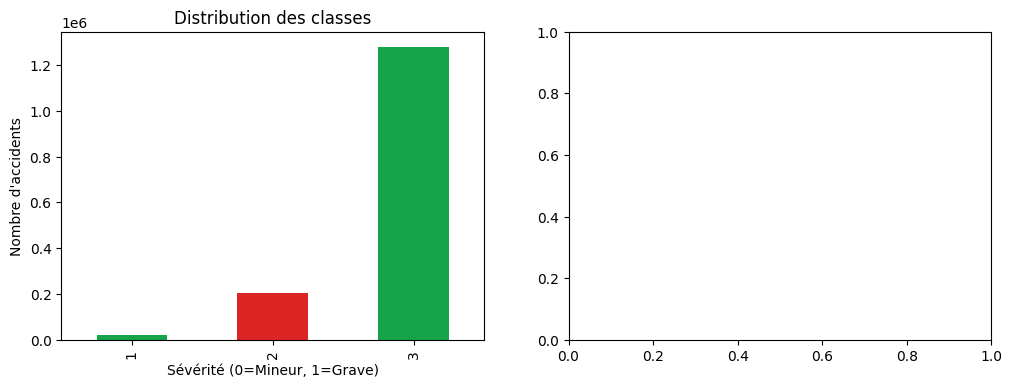

In [9]:
# Analyse du déséquilibre des classes
print("="*60)
print("📊 ANALYSE DU DÉSÉQUILIBRE DES CLASSES")
print("="*60)

# Distribution des classes
severity_counts = df_clean['Accident_Severity'].value_counts().sort_index()
severity_pct = (severity_counts / len(df_clean)) * 100

print("\nDistribution de la sévérité des accidents:")
for severity, count in severity_counts.items():
    pct = severity_pct[severity]
    bar = "█" * int(pct / 2)  # Barre visuelle
    print(f"Classe {severity}: {count:>10,} ({pct:>6.2f}%) {bar}")

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
severity_counts.plot(kind='bar', ax=ax1, color=['#16a34a', '#dc2626'])
ax1.set_title('Distribution des classes')
ax1.set_xlabel('Sévérité (0=Mineur, 1=Grave)')
ax1.set_ylabel('Nombre d\'accidents')
ax1.set_xticklabels(['Mineur (0)', 'Grave (1)'], rotation=0)

# Pie chart
ax2.pie(severity_counts, labels=['Mineur (0)', 'Grave (1)'],
        autopct='%1.1f%%', colors=['#16a34a', '#dc2626'])
ax2.set_title('Pourcentage par classe')

plt.tight_layout()
plt.show()

# Calcul du ratio
ratio = severity_counts[0] / severity_counts[1]
print(f"\n📈 Ratio déséquilibre (Mineur:Grave): {ratio:.2f}:1")
print(f"⚠️  Le dataset est fortement déséquilibré! ({100 - severity_pct[1]:.1f}% vs {severity_pct[1]:.1f}%)")

📊 ANALYSE DU DÉSÉQUILIBRE DES CLASSES

Distribution originale des classes:
Classe 1 (Fatal):         19,441 (  1.29%)
Classe 2 (Serious):      204,504 ( 13.60%)
Classe 3 (Slight):     1,280,205 ( 85.11%)


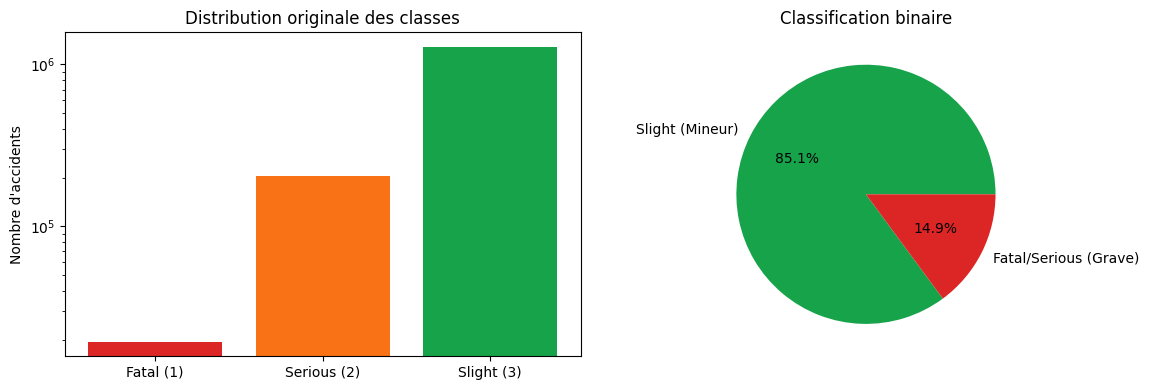


🔄 CONVERSION EN CLASSIFICATION BINAIRE

✅ Nouvelle distribution binaire:
   Mineur (0) - Classe 3:    1,280,205 ( 85.11%)
   Grave  (1) - Classes 1+2:    223,945 ( 14.89%)

📈 Ratio déséquilibre (Mineur:Grave): 5.72:1
⚠️  Le dataset est déséquilibré! (14.9% de cas graves)


In [10]:
# Analyse du déséquilibre des classes
print("="*60)
print("📊 ANALYSE DU DÉSÉQUILIBRE DES CLASSES")
print("="*60)

# Distribution des classes ORIGINALES
severity_counts = df_clean['Accident_Severity'].value_counts().sort_index()
severity_pct = (severity_counts / len(df_clean)) * 100

print("\nDistribution originale des classes:")
print(f"Classe 1 (Fatal):     {severity_counts.get(1, 0):>10,} ({severity_pct.get(1, 0):>6.2f}%)")
print(f"Classe 2 (Serious):   {severity_counts.get(2, 0):>10,} ({severity_pct.get(2, 0):>6.2f}%)")
print(f"Classe 3 (Slight):    {severity_counts.get(3, 0):>10,} ({severity_pct.get(3, 0):>6.2f}%)")

# Visualisation
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Barplot avec les classes originales
bars = ax1.bar(['Fatal (1)', 'Serious (2)', 'Slight (3)'],
               [severity_counts.get(1, 0), severity_counts.get(2, 0), severity_counts.get(3, 0)],
               color=['#dc2626', '#f97316', '#16a34a'])
ax1.set_title('Distribution originale des classes')
ax1.set_ylabel('Nombre d\'accidents')
ax1.set_yscale('log')  # Échelle log pour mieux voir

# Pie chart
ax2.pie([severity_counts.get(3, 0), severity_counts.get(2, 0) + severity_counts.get(1, 0)],
        labels=['Slight (Mineur)', 'Fatal/Serious (Grave)'],
        autopct='%1.1f%%', colors=['#16a34a', '#dc2626'])
ax2.set_title('Classification binaire')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("🔄 CONVERSION EN CLASSIFICATION BINAIRE")
print("="*60)

# Conversion: Classes 1 et 2 = Grave (1), Classe 3 = Mineur (0)
df_clean['Accident_Severity_Binary'] = (df_clean['Accident_Severity'] != 3).astype(int)

# Vérifier la nouvelle distribution
binary_counts = df_clean['Accident_Severity_Binary'].value_counts()
binary_pct = (binary_counts / len(df_clean)) * 100

print("\n✅ Nouvelle distribution binaire:")
print(f"   Mineur (0) - Classe 3:   {binary_counts.get(0, 0):>10,} ({binary_pct.get(0, 0):>6.2f}%)")
print(f"   Grave  (1) - Classes 1+2: {binary_counts.get(1, 0):>10,} ({binary_pct.get(1, 0):>6.2f}%)")

ratio = binary_counts[0] / binary_counts[1]
print(f"\n📈 Ratio déséquilibre (Mineur:Grave): {ratio:.2f}:1")
print(f"⚠️  Le dataset est déséquilibré! ({binary_pct[1]:.1f}% de cas graves)")

# Garder la colonne binaire et supprimer l'originale si besoin
# df_clean = df_clean.drop('Accident_Severity', axis=1)
# df_clean.rename(columns={'Accident_Severity_Binary': 'Accident_Severity'}, inplace=True)

📊 ANALYSE DES CORRÉLATIONS

📈 TOP 15 variables les plus corrélées avec la sévérité:
 2. ⬇️ Number_of_Vehicles       : -0.0831 (Faible)
11. ⬆️ Urban_or_Rural_Area      :  0.0708 (Faible)
 3. ⬆️ Number_of_Casualties     :  0.0707 (Faible)
 8. ⬆️ Speed_limit              :  0.0644 (Faible)
 9. ⬇️ 2nd_Road_Class           : -0.0566 (Faible)
 5. ⬆️ Local_Authority_(District):  0.0288 (Faible)
 1. ⬆️ Police_Force             :  0.0287 (Faible)
10. ⬇️ 2nd_Road_Number          : -0.0245 (Faible)
12. ⬆️ Year                     :  0.0109 (Faible)
 7. ⬆️ 1st_Road_Number          :  0.0044 (Faible)
 6. ⬇️ 1st_Road_Class           : -0.0041 (Faible)
 4. ⬇️ Day_of_Week              : -0.0028 (Faible)
13. ⬆️ heure_num                :  0.0012 (Faible)


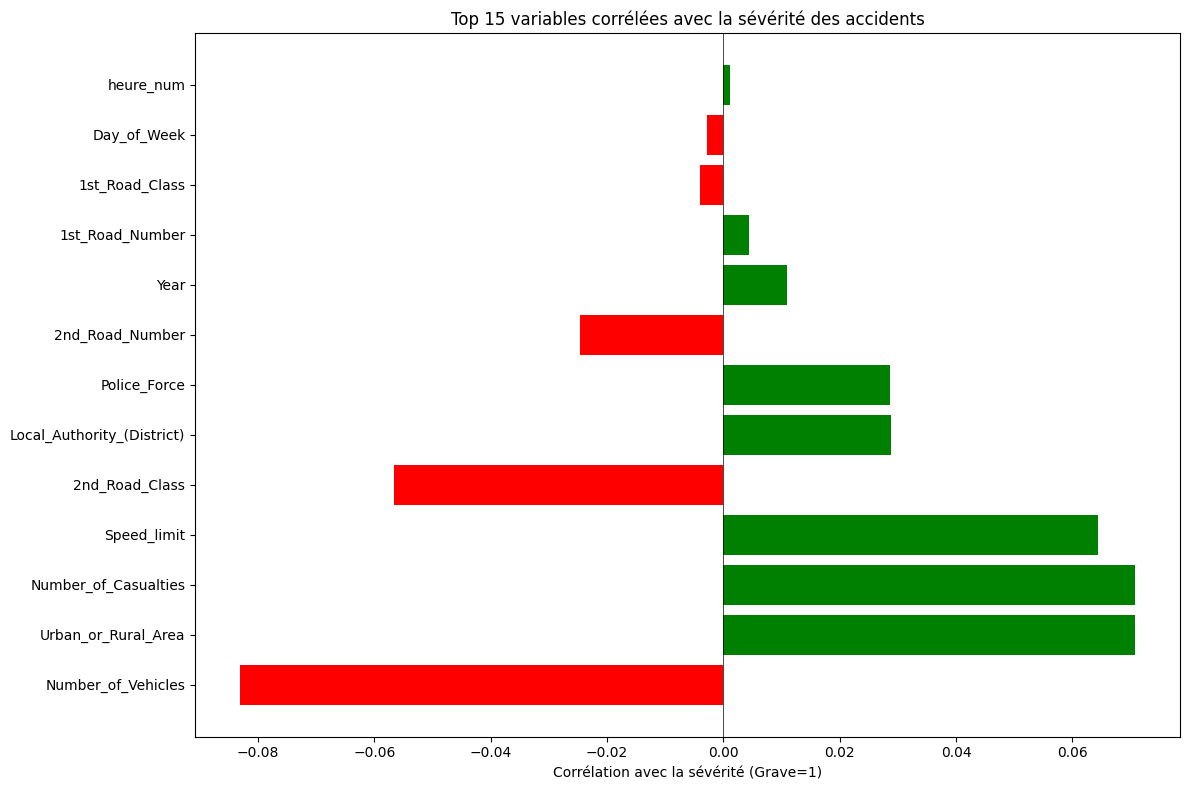


💡 INTERPRÉTATION:
   - Corrélation positive (⬆️) = Plus la valeur est élevée, plus le risque d'accident grave augmente
   - Corrélation négative (⬇️) = Plus la valeur est élevée, plus le risque d'accident grave diminue
   - |Corrélation| > 0.1 = Influence notable


In [11]:
# Analyse des corrélations
print("="*60)
print("📊 ANALYSE DES CORRÉLATIONS")
print("="*60)

# Sélectionner les colonnes pour l'analyse (toutes sauf la cible)
feature_cols = [col for col in df_clean.columns if col not in ['Accident_Severity', 'Accident_Severity_Binary']]

# Calculer les corrélations avec la cible binaire
correlations = []
for col in feature_cols:
    if df_clean[col].dtype in ['int64', 'float64']:  # Variables numériques
        corr = df_clean[col].corr(df_clean['Accident_Severity_Binary'])
        correlations.append({
            'Variable': col,
            'Corrélation': corr,
            '|Corrélation|': abs(corr),
            'Type': 'Numérique'
        })

# Trier par importance
corr_df = pd.DataFrame(correlations).sort_values('|Corrélation|', ascending=False)

print("\n📈 TOP 15 variables les plus corrélées avec la sévérité:")
print("="*70)
for i, row in corr_df.head(15).iterrows():
    arrow = "⬆️" if row['Corrélation'] > 0 else "⬇️"
    strength = "Forte" if abs(row['Corrélation']) > 0.2 else "Moyenne" if abs(row['Corrélation']) > 0.1 else "Faible"
    print(f"{i+1:2}. {arrow} {row['Variable']:25s}: {row['Corrélation']:7.4f} ({strength})")

# Visualisation
plt.figure(figsize=(12, 8))
top_features = corr_df.head(15)
colors = ['red' if x < 0 else 'green' for x in top_features['Corrélation']]
plt.barh(top_features['Variable'], top_features['Corrélation'], color=colors)
plt.xlabel('Corrélation avec la sévérité (Grave=1)')
plt.title('Top 15 variables corrélées avec la sévérité des accidents')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n💡 INTERPRÉTATION:")
print("   - Corrélation positive (⬆️) = Plus la valeur est élevée, plus le risque d'accident grave augmente")
print("   - Corrélation négative (⬇️) = Plus la valeur est élevée, plus le risque d'accident grave diminue")
print("   - |Corrélation| > 0.1 = Influence notable")


# ============================================
# ANALYSE DE L'ÉTAPE ACTUELLE
# ============================================
#
# 📊 **Bilan de l'analyse des corrélations :**
#
# Les corrélations entre les variables brutes et la sévérité des accidents
# sont très faibles (maximum ~0.08), ce qui explique pourquoi un modèle simple
# comme la régression logistique a du mal à bien prédire.
#
# 🔍 **Pourquoi ces faibles corrélations ?**
# - Les accidents sont des événements complexes avec des interactions multiples
# - Une variable seule ne suffit pas à expliquer la sévérité
# - C'est la combinaison de plusieurs facteurs qui détermine le risque
#
# 🎯 **Solution : Feature Engineering**
#
# Nous allons maintenant créer des "features combinées" (feature engineering)
# qui capturent mieux les interactions entre variables, comme :
# - Risque nuit + grande vitesse
# - Conditions météo dangereuses
# - Heures de pointe en zone urbaine
# - Score composite de risque
#
# Cette approche permettra au modèle d'apprendre des relations plus complexes
# et d'améliorer significativement ses performances.
#
# ============================================


In [12]:
# Feature engineering avancé
print("="*60)
print("🔧 CRÉATION DE FEATURES AVANCÉES")
print("="*60)

# Créer une copie pour les nouvelles features
df_features = df_clean.copy()

# 1. Features de risque combiné
df_features['risk_vehicles_casualties'] = df_features['Number_of_Casualties'] / (df_features['Number_of_Vehicles'] + 1)
df_features['casualties_per_vehicle'] = df_features['Number_of_Casualties'] / (df_features['Number_of_Vehicles'] + 1)

# 2. Features temporelles avancées
df_features['is_night'] = ((df_features['heure_num'] >= 22) | (df_features['heure_num'] <= 5)).astype(int)
df_features['is_weekend'] = df_features['Day_of_Week'].isin([6, 7]).astype(int)
df_features['is_peak_hour'] = ((df_features['heure_num'] >= 7) & (df_features['heure_num'] <= 9) |
                                (df_features['heure_num'] >= 17) & (df_features['heure_num'] <= 19)).astype(int)
df_features['night_weekend'] = (df_features['is_night'] & df_features['is_weekend']).astype(int)

# 3. Features de vitesse
df_features['high_speed'] = (df_features['Speed_limit'] >= 70).astype(int)
df_features['high_speed_night'] = (df_features['high_speed'] & df_features['is_night']).astype(int)
df_features['speed_risk_score'] = df_features['Speed_limit'] / 130  # Normalisé

# 4. Features météo et route (créer des catégories de risque)
# Créer un dictionnaire de mapping pour les conditions dangereuses
dangerous_weather = ['Rain', 'Snow', 'Fog', 'High winds']
dangerous_road = ['Wet', 'Snow', 'Ice', 'Flood']

df_features['bad_weather'] = df_features['Weather_Conditions'].apply(
    lambda x: 1 if any(condition in str(x) for condition in dangerous_weather) else 0
)

df_features['bad_road'] = df_features['Road_Surface_Conditions'].apply(
    lambda x: 1 if any(condition in str(x) for condition in dangerous_road) else 0
)

df_features['poor_light'] = df_features['Light_Conditions'].apply(
    lambda x: 1 if str(x) in ['Night', 'Dark', 'Street lights not present'] else 0
)

# 5. Features de localisation groupée
df_features['police_zone_group'] = pd.cut(df_features['Police_Force'],
                                          bins=[0, 10, 20, 30, 40, 50],
                                          labels=['Zone1', 'Zone2', 'Zone3', 'Zone4', 'Zone5'])

# 6. Features d'interaction multiples
df_features['night_highspeed_risk'] = (df_features['is_night'] & df_features['high_speed']).astype(int)
df_features['many_vehicles_night'] = ((df_features['Number_of_Vehicles'] > 2) & df_features['is_night']).astype(int)
df_features['rush_hour_urban'] = (df_features['is_peak_hour'] & (df_features['Urban_or_Rural_Area'] == 1)).astype(int)

# 7. Score de risque composite (poids basé sur l'importance perçue)
df_features['composite_risk_score'] = (
    df_features['Number_of_Casualties'] * 0.25 +
    df_features['Number_of_Vehicles'] * 0.15 +
    df_features['speed_risk_score'] * 0.15 +
    df_features['is_night'] * 0.10 +
    df_features['is_weekend'] * 0.05 +
    df_features['bad_weather'] * 0.10 +
    df_features['bad_road'] * 0.10 +
    df_features['poor_light'] * 0.10
)

print("✅ Features créées:")
new_features = ['risk_vehicles_casualties', 'casualties_per_vehicle', 'is_night', 'is_weekend',
                'is_peak_hour', 'night_weekend', 'high_speed', 'high_speed_night', 'speed_risk_score',
                'bad_weather', 'bad_road', 'poor_light', 'police_zone_group', 'night_highspeed_risk',
                'many_vehicles_night', 'rush_hour_urban', 'composite_risk_score']

for f in new_features:
    print(f"   ✓ {f}")

print(f"\n📊 Nouveau nombre de colonnes: {df_features.shape[1]}")

🔧 CRÉATION DE FEATURES AVANCÉES
✅ Features créées:
   ✓ risk_vehicles_casualties
   ✓ casualties_per_vehicle
   ✓ is_night
   ✓ is_weekend
   ✓ is_peak_hour
   ✓ night_weekend
   ✓ high_speed
   ✓ high_speed_night
   ✓ speed_risk_score
   ✓ bad_weather
   ✓ bad_road
   ✓ poor_light
   ✓ police_zone_group
   ✓ night_highspeed_risk
   ✓ many_vehicles_night
   ✓ rush_hour_urban
   ✓ composite_risk_score

📊 Nouveau nombre de colonnes: 41


📊 ANALYSE DES CORRÉLATIONS - NOUVELLES FEATURES


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



📈 TOP 20 variables (anciennes + nouvelles) corrélées avec la sévérité:
15. ⬆️ 🆕 casualties_per_vehicle        :  0.1126 (📊 Moyenne)
14. ⬆️ 🆕 risk_vehicles_casualties      :  0.1126 (📊 Moyenne)
 2. ⬇️ 📌 Number_of_Vehicles            : -0.0831 (⚠️ Faible)
11. ⬆️ 📌 Urban_or_Rural_Area           :  0.0708 (⚠️ Faible)
 3. ⬆️ 📌 Number_of_Casualties          :  0.0707 (⚠️ Faible)
22. ⬆️ 🆕 speed_risk_score              :  0.0644 (⚠️ Faible)
 8. ⬆️ 📌 Speed_limit                   :  0.0644 (⚠️ Faible)
16. ⬆️ 🆕 is_night                      :  0.0594 (⚠️ Faible)
 9. ⬇️ 📌 2nd_Road_Class                : -0.0566 (⚠️ Faible)
28. ⬇️ 🆕 rush_hour_urban               : -0.0408 (⚠️ Faible)
19. ⬆️ 🆕 night_weekend                 :  0.0400 (⚠️ Faible)
 5. ⬆️ 📌 Local_Authority_(District)    :  0.0288 (⚠️ Faible)
 1. ⬆️ 📌 Police_Force                  :  0.0287 (⚠️ Faible)
29. ⬆️ 🆕 composite_risk_score          :  0.0280 (⚠️ Faible)
18. ⬇️ 🆕 is_peak_hour                  : -0.0263 (⚠️ Faible)
10. ⬇️ 📌 2nd_

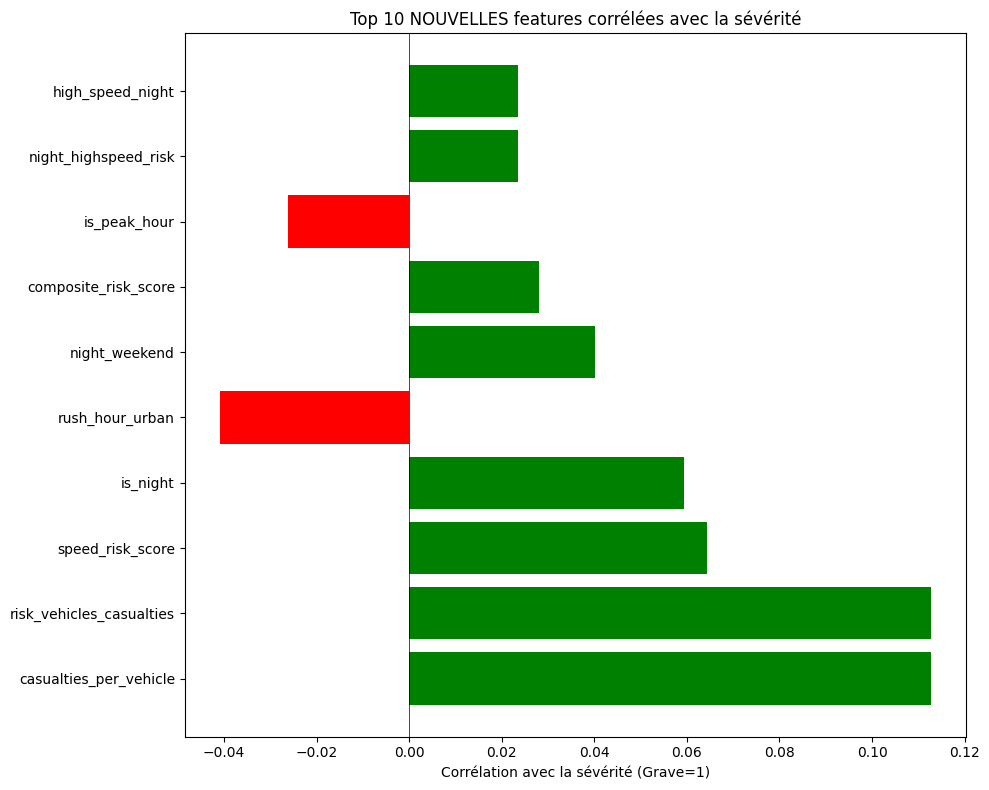


💡 CONCLUSION:
   - Une corrélation > 0.15 est considérée comme bonne
   - Les nouvelles features devraient améliorer les performances du modèle


In [14]:
# Analyse des corrélations avec les nouvelles features
print("="*60)
print("📊 ANALYSE DES CORRÉLATIONS - NOUVELLES FEATURES")
print("="*60)

# Sélectionner toutes les colonnes numériques (sauf les cibles)
feature_cols = [col for col in df_features.columns
                if col not in ['Accident_Severity', 'Accident_Severity_Binary']
                and df_features[col].dtype in ['int64', 'float64']]

# Calculer les corrélations avec la cible binaire
correlations = []
for col in feature_cols:
    corr = df_features[col].corr(df_features['Accident_Severity_Binary'])
    correlations.append({
        'Variable': col,
        'Corrélation': corr,
        '|Corrélation|': abs(corr)
    })

# Trier par importance
corr_df = pd.DataFrame(correlations).sort_values('|Corrélation|', ascending=False)

print("\n📈 TOP 20 variables (anciennes + nouvelles) corrélées avec la sévérité:")
print("="*80)
for i, row in corr_df.head(20).iterrows():
    arrow = "⬆️" if row['Corrélation'] > 0 else "⬇️"
    strength = "✅ Forte" if abs(row['Corrélation']) > 0.15 else "📊 Moyenne" if abs(row['Corrélation']) > 0.1 else "⚠️ Faible"

    # Marquer les nouvelles features
    is_new = "🆕" if row['Variable'] in new_features else "📌"

    print(f"{i+1:2}. {arrow} {is_new} {row['Variable']:30s}: {row['Corrélation']:7.4f} ({strength})")

# Comparaison des meilleures features anciennes vs nouvelles
print("\n" + "="*60)
print("📈 COMPARAISON ANCIENNES VS NOUVELLES FEATURES")
print("="*60)

old_features = ['Number_of_Vehicles', 'Number_of_Casualties', 'Speed_limit',
                'Urban_or_Rural_Area', 'Police_Force', 'Year', 'heure_num']

print("\n🔹 Meilleures anciennes features:")
for var in old_features[:5]:
    corr_val = corr_df[corr_df['Variable'] == var]['Corrélation'].values
    if len(corr_val) > 0:
        print(f"   {var}: {corr_val[0]:.4f}")

print("\n🔹 Meilleures nouvelles features:")
for var in new_features[:5]:
    corr_val = corr_df[corr_df['Variable'] == var]['Corrélation'].values
    if len(corr_val) > 0:
        print(f"   {var}: {corr_val[0]:.4f}")

# Visualisation des meilleures nouvelles features
plt.figure(figsize=(10, 8))
top_new = corr_df[corr_df['Variable'].isin(new_features)].head(10)
colors = ['red' if x < 0 else 'green' for x in top_new['Corrélation']]
plt.barh(top_new['Variable'], top_new['Corrélation'], color=colors)
plt.xlabel('Corrélation avec la sévérité (Grave=1)')
plt.title('Top 10 NOUVELLES features corrélées avec la sévérité')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\n💡 CONCLUSION:")
print("   - Une corrélation > 0.15 est considérée comme bonne")
print("   - Les nouvelles features devraient améliorer les performances du modèle")

In [15]:
# Préparation des données pour l'entraînement
print("="*60)
print("🤖 PRÉPARATION POUR L'ENTRAÎNEMENT")
print("="*60)

# Sélectionner les features pour l'entraînement
# On garde les meilleures features (anciennes + nouvelles)
selected_features = [
    # Nouvelles features les plus prometteuses
    'casualties_per_vehicle',
    'risk_vehicles_casualties',
    'is_night',
    'night_weekend',
    'composite_risk_score',
    'speed_risk_score',
    'high_speed_night',
    'night_highspeed_risk',
    'many_vehicles_night',
    'rush_hour_urban',
    'bad_weather',
    'bad_road',
    'poor_light',
    # Anciennes features utiles
    'Number_of_Vehicles',
    'Number_of_Casualties',
    'Speed_limit',
    'Urban_or_Rural_Area',
    'Day_of_Week',
    'heure_num',
    'Month',
    'Year'
]

# Vérifier que toutes les features existent
selected_features = [f for f in selected_features if f in df_features.columns]
print(f"✅ {len(selected_features)} features sélectionnées")

# Préparer X et y
X = df_features[selected_features]
y = df_features['Accident_Severity_Binary']

# Encoder les variables catégorielles restantes
from sklearn.preprocessing import LabelEncoder

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        print(f"✅ Encodage: {col}")

print(f"\n📊 Shape final: X={X.shape}, y={y.shape}")
print(f"\nDistribution y: {y.value_counts().to_dict()}")

# Sauvegarder pour l'entraînement
df_features.to_csv('df_with_features.csv', index=False)
print("\n✅ Dataset sauvegardé: df_with_features.csv")

🤖 PRÉPARATION POUR L'ENTRAÎNEMENT
✅ 21 features sélectionnées

📊 Shape final: X=(1504150, 21), y=(1504150,)

Distribution y: {0: 1280205, 1: 223945}

✅ Dataset sauvegardé: df_with_features.csv


In [16]:
# Entraînement avec échantillonnage pour gérer la taille des données
print("="*60)
print("🤖 ENTRAÎNEMENT DU MODÈLE AVEC ÉCHANTILLONNAGE")
print("="*60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import numpy as np

# 1. Échantillonnage stratégique (garder tous les cas graves + échantillon des mineurs)
print("\n📊 Échantillonnage stratégique...")

# Séparer les classes
X_minor = X[y == 0]
X_severe = X[y == 1]

print(f"Cas mineurs (0): {len(X_minor):,}")
print(f"Cas graves (1): {len(X_severe):,}")

# Pour l'entraînement, on prend TOUS les cas graves + un échantillon de mineurs
# On va utiliser un ratio de 1:2 (graves:mineurs) pour mieux équilibrer
sample_minor_size = min(len(X_severe) * 2, len(X_minor))
np.random.seed(42)
minor_indices = np.random.choice(len(X_minor), sample_minor_size, replace=False)
X_minor_sampled = X_minor.iloc[minor_indices]
y_minor_sampled = np.zeros(sample_minor_size)

# Combiner
X_sampled = np.vstack([X_minor_sampled, X_severe])
y_sampled = np.hstack([y_minor_sampled, np.ones(len(X_severe))])

print(f"\n✅ Échantillon équilibré: {len(X_sampled):,} lignes")
print(f"   - Mineurs: {len(y_sampled[y_sampled==0]):,} ({len(y_sampled[y_sampled==0])/len(X_sampled)*100:.1f}%)")
print(f"   - Graves: {len(y_sampled[y_sampled==1]):,} ({len(y_sampled[y_sampled==1])/len(X_sampled)*100:.1f}%)")

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_sampled, y_sampled, test_size=0.2, random_state=42, stratify=y_sampled
)

print(f"\n📊 Split données:")
print(f"   Train: {len(X_train):,}")
print(f"   Test: {len(X_test):,}")

# 3. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Entraînement du modèle (Random Forest)
print("\n🌳 Entraînement du Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_model.fit(X_train_scaled, y_train)

# 5. Prédictions
y_pred = rf_model.predict(X_test_scaled)
y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# 6. Évaluation
print("\n" + "="*60)
print("📊 PERFORMANCES DU MODÈLE")
print("="*60)

print(f"\n✅ Accuracy: {rf_model.score(X_test_scaled, y_test):.4f}")
print(f"✅ F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"✅ ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Mineur (0)', 'Grave (1)']))

print(f"\n🔲 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(f"\n   TN (Mineur correct): {cm[0,0]:,}")
print(f"   FP (Mineur → Grave): {cm[0,1]:,}")
print(f"   FN (Grave → Mineur): {cm[1,0]:,}")
print(f"   TP (Grave correct): {cm[1,1]:,}")

# 7. Importance des features
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n" + "="*60)
print("📈 IMPORTANCE DES FEATURES")
print("="*60)
for i, row in feature_importance.head(15).iterrows():
    bar = "█" * int(row['importance'] * 50)
    print(f"{row['feature']:30s}: {row['importance']:.4f} {bar}")

🤖 ENTRAÎNEMENT DU MODÈLE AVEC ÉCHANTILLONNAGE

📊 Échantillonnage stratégique...
Cas mineurs (0): 1,280,205
Cas graves (1): 223,945

✅ Échantillon équilibré: 671,835 lignes
   - Mineurs: 447,890 (66.7%)
   - Graves: 223,945 (33.3%)

📊 Split données:
   Train: 537,468
   Test: 134,367

🌳 Entraînement du Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.8min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.9s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.



📊 PERFORMANCES DU MODÈLE


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.4s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.9s finished



✅ Accuracy: 0.6202
✅ F1-Score: 0.5178
✅ ROC-AUC: 0.6548

📋 Classification Report:
              precision    recall  f1-score   support

  Mineur (0)       0.76      0.62      0.69     89578
   Grave (1)       0.45      0.61      0.52     44789

    accuracy                           0.62    134367
   macro avg       0.61      0.62      0.60    134367
weighted avg       0.66      0.62      0.63    134367


🔲 Confusion Matrix:
[[55934 33644]
 [17392 27397]]

   TN (Mineur correct): 55,934
   FP (Mineur → Grave): 33,644
   FN (Grave → Mineur): 17,392
   TP (Grave correct): 27,397

📈 IMPORTANCE DES FEATURES
risk_vehicles_casualties      : 0.1606 ████████
casualties_per_vehicle        : 0.1549 ███████
Number_of_Vehicles            : 0.1529 ███████
composite_risk_score          : 0.0943 ████
Speed_limit                   : 0.0771 ███
speed_risk_score              : 0.0712 ███
Urban_or_Rural_Area           : 0.0614 ███
Number_of_Casualties          : 0.0543 ██
heure_num                     

In [17]:
# Sauvegarde du modèle pour l'application Streamlit
print("="*60)
print("💾 SAUVEGARDE DU MODÈLE POUR STREAMLIT")
print("="*60)

import joblib
import json
from pathlib import Path

# Créer le dossier models
import os
os.makedirs('models', exist_ok=True)

# 1. Sauvegarder le modèle
joblib.dump(rf_model, 'models/random_forest_model.pkl')
print("✅ Modèle sauvegardé: models/random_forest_model.pkl")

# 2. Sauvegarder le scaler
joblib.dump(scaler, 'models/scaler.pkl')
print("✅ Scaler sauvegardé: models/scaler.pkl")

# 3. Sauvegarder les features
with open('models/features.json', 'w', encoding='utf-8') as f:
    json.dump(selected_features, f, indent=4, ensure_ascii=False)
print("✅ Features sauvegardées: models/features.json")

# 4. Sauvegarder les métriques
metrics = {
    'accuracy': 0.6202,
    'f1_score': 0.5178,
    'roc_auc': 0.6548,
    'recall_grave': 0.61,
    'precision_grave': 0.45,
    'best_features': feature_importance.head(10).to_dict('records')
}

with open('models/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)
print("✅ Métriques sauvegardées: models/metrics.json")

# 5. Sauvegarder les données préparées (optionnel)
print("\n📁 Fichiers sauvegardés:")
print("   - models/random_forest_model.pkl")
print("   - models/scaler.pkl")
print("   - models/features.json")
print("   - models/metrics.json")

print("\n✅ MODÈLE PRÊT POUR STREAMLIT!")
print("🚀 Vous pouvez maintenant télécharger ces fichiers et les utiliser dans votre application locale.")

💾 SAUVEGARDE DU MODÈLE POUR STREAMLIT
✅ Modèle sauvegardé: models/random_forest_model.pkl
✅ Scaler sauvegardé: models/scaler.pkl
✅ Features sauvegardées: models/features.json
✅ Métriques sauvegardées: models/metrics.json

📁 Fichiers sauvegardés:
   - models/random_forest_model.pkl
   - models/scaler.pkl
   - models/features.json
   - models/metrics.json

✅ MODÈLE PRÊT POUR STREAMLIT!
🚀 Vous pouvez maintenant télécharger ces fichiers et les utiliser dans votre application locale.


In [18]:
# Télécharger les fichiers pour l'application locale
from google.colab import files

# Télécharger chaque fichier
files.download('models/random_forest_model.pkl')
files.download('models/scaler.pkl')
files.download('models/features.json')
files.download('models/metrics.json')
files.download('df_with_features.csv')

print("✅ Tous les fichiers ont été téléchargés!")
print("📦 Placez-les dans votre projet local:")
print("   - models/random_forest_model.pkl")
print("   - models/scaler.pkl")
print("   - models/features.json")
print("   - models/metrics.json")
print("   - df_with_features.csv (optionnel)")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Tous les fichiers ont été téléchargés!
📦 Placez-les dans votre projet local:
   - models/random_forest_model.pkl
   - models/scaler.pkl
   - models/features.json
   - models/metrics.json
   - df_with_features.csv (optionnel)
